# Imports

In [5]:
import os
import time
import psutil
import librosa
import queue
import threading
import numpy as np
import pandas as pd
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from concurrent.futures import ThreadPoolExecutor

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Configuration

In [6]:
# Config
DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/music/Train"
SAMPLE_RATE = 22050
DURATION = 5
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION

# Extract Mel-spectogram from audio

In [7]:
# Function to extract Mel-spectrogram from audio
def extract_mel_spectrogram(file_path, sr=22050, duration=5, max_len=216):
    y, sr = librosa.load(file_path, sr=sr, duration=duration)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    if mel_db.shape[1] < max_len:
        pad_width = max_len - mel_db.shape[1]
        mel_db = np.pad(mel_db, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        mel_db = mel_db[:, :max_len]
    return mel_db

# Prepare data

*   collect all audio file paths and labels
*   Process files using ThreadPoolExecutor
*   Preprocess data
*   Train/Test split

# Thread Pool Executor

In [4]:
start_time = time.time()
process = psutil.Process(os.getpid())
start_mem = process.memory_info().rss / 1024 / 1024
# ThreadPool-based processing function
def process_file_thread(file_path, label):
    try:
        mel = extract_mel_spectrogram(file_path)
        return mel, label
    except Exception as e:
        print(f"Error: {file_path}, {e}")
        return None

# Collect all audio file paths and labels
tasks = []
for label in os.listdir(DATASET_PATH):
    folder = os.path.join(DATASET_PATH, label)
    if not os.path.isdir(folder):
        continue
    for file_name in os.listdir(folder):
        if file_name.endswith(".mp3") or file_name.endswith(".wav"):
            file_path = os.path.join(folder, file_name)
            tasks.append((file_path, label))

def monitor_threads():
    # Print the number of active threads
    print(f"Active threads: {threading.active_count()}")

# Process files using ThreadPoolExecutor
with ThreadPoolExecutor(max_workers=4) as executor:
    results = list(executor.map(lambda args: process_file_thread(*args), tasks))
    monitor_threads()

# Filter out None results
features = [res[0] for res in results if res is not None]
labels = [res[1] for res in results if res is not None]

# Preprocess data
X = np.array(features)[..., np.newaxis]  # Add channel dimension
y = to_categorical(LabelEncoder().fit_transform(labels))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

end_mem = process.memory_info().rss / 1024 / 1024
end_time = time.time()
print(f"Memory Used: {end_mem - start_mem:.2f} MB")
print(f"Time Taken: {end_time - start_time:.2f} seconds")

Active threads: 7
Memory Used: 200.82 MB
Time Taken: 30.40 seconds


# Multithreading

In [8]:
start_time = time.time()
process = psutil.Process(os.getpid())
start_mem = process.memory_info().rss / 1024 / 1024

# Collect all audio file paths and labels
tasks = []
for label in os.listdir(DATASET_PATH):
    folder = os.path.join(DATASET_PATH, label)
    if not os.path.isdir(folder):
        continue
    for file_name in os.listdir(folder):
        if file_name.endswith(".mp3") or file_name.endswith(".wav"):
            file_path = os.path.join(folder, file_name)
            tasks.append((file_path, label))

# Create a thread-safe queue to store results
results_queue = queue.Queue()

# Worker function for threads
def thread_worker(file_path, label):
    try:
        mel = extract_mel_spectrogram(file_path)
        results_queue.put((mel, label))
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# Create and start threads
threads = []
for file_path, label in tasks:
    thread = threading.Thread(target=thread_worker, args=(file_path, label))
    thread.start()
    threads.append(thread)

# Wait for all threads to finish
for thread in threads:
    thread.join()

# Collect results
results = list(results_queue.queue)

# Filter out None results
features = [res[0] for res in results if res is not None]
labels = [res[1] for res in results if res is not None]

# Preprocess data
X = np.array(features)[..., np.newaxis]  # Add channel dimension
y = to_categorical(LabelEncoder().fit_transform(labels))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

end_mem = process.memory_info().rss / 1024 / 1024
end_time = time.time()
print(f"Memory Used: {end_mem - start_mem:.2f} MB")
print(f"Time Taken: {end_time - start_time:.2f} seconds")

Memory Used: 427.77 MB
Time Taken: 6.15 seconds


# Dataframe

In [9]:
df = pd.DataFrame(tasks, columns=["file_path", "label"])
df.head()

,file_path,label
0,/content/drive/MyDrive/Colab Notebooks/music/T...,Drum
1,/content/drive/MyDrive/Colab Notebooks/music/T...,Drum
2,/content/drive/MyDrive/Colab Notebooks/music/T...,Drum
3,/content/drive/MyDrive/Colab Notebooks/music/T...,Drum
4,/content/drive/MyDrive/Colab Notebooks/music/T...,Drum


In [10]:
df.tail()

,file_path,label
195,/content/drive/MyDrive/Colab Notebooks/music/T...,Guitar
196,/content/drive/MyDrive/Colab Notebooks/music/T...,Guitar
197,/content/drive/MyDrive/Colab Notebooks/music/T...,Guitar
198,/content/drive/MyDrive/Colab Notebooks/music/T...,Guitar
199,/content/drive/MyDrive/Colab Notebooks/music/T...,Guitar


# Data after extract mel-spectogram

In [11]:
# List to store flattened Mel-spectrograms and their labels
mel_db_list = [] #Store Mel-spectrograms (flattened)
labels = [] #Store corresponding labels

# Loop through dataset and extract Mel-spectrograms
for label in os. listdir(DATASET_PATH):
  folder = os.path. join(DATASET_PATH, label)
  if not os. path. isdir(folder):
    continue
  for file_name in os. listdir(folder):
    if file_name.endswith(".mp3") or file_name.endswith(".wav"):
      file_path = os. path. join (folder, file_name)
      try:
          mel_db = extract_mel_spectrogram (file_path)
          mel_db_flat = mel_db.flatten() # Flatten the Mel-spectrogram to a 1D array
          mel_db_list.append (mel_db_flat) # Add flattened Mel-spectrogram to list
          labels. append (label) # Add label to list
      except Exception as e:
          print(f"Error processing (file_path): {e}")

# Convert list of Mel-spectrograms to a pandas DataFrame
mel_db_df = pd. DataFrame(mel_db_list)

# Add a column for the labels
mel_db_df ['Label'] = labels

# Display the first few rows of the table
print (mel_db_df. head ())

# Optionally, save the DataFrame to a CSV file
mel_db_df.to_csv('mel_spectrograms_table.csv', index=False)

           0          1          2          3          4          5  \
0 -80.000000 -80.000000 -80.000000 -80.000000 -80.000000 -79.124062   
1 -80.000000 -80.000000 -80.000000 -80.000000 -80.000000 -80.000000   
2 -80.000000 -80.000000 -80.000000 -80.000000 -80.000000 -80.000000   
3 -80.000000 -80.000000 -80.000000 -80.000000 -80.000000 -80.000000   
4 -21.439396 -24.262081 -31.258314 -35.686424 -34.703232 -40.121719   

           6          7          8          9  ...     27639      27640  \
0 -65.742027 -31.005043 -16.331795 -10.886230  ... -80.00000 -80.000000   
1 -80.000000 -80.000000 -80.000000 -80.000000  ... -80.00000 -80.000000   
2 -80.000000 -80.000000 -80.000000 -80.000000  ... -80.00000 -80.000000   
3 -80.000000 -80.000000 -80.000000 -80.000000  ... -80.00000 -80.000000   
4 -49.910576 -48.545334 -54.278671 -58.762661  ... -65.74472 -70.877197   

       27641      27642      27643      27644      27645      27646  27647  \
0 -80.000000 -80.000000 -80.000000 -80.00000

# Define and Train model

In [12]:
# Define CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=X_train.shape[1:]),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(y.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 428ms/step - accuracy: 0.2867 - loss: 260.8062 - val_accuracy: 0.3500 - val_loss: 3.8204
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.3735 - loss: 13.2100 - val_accuracy: 0.2250 - val_loss: 1.3614
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3706 - loss: 1.2786 - val_accuracy: 0.2500 - val_loss: 1.3431
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4024 - loss: 1.1059 - val_accuracy: 0.2750 - val_loss: 1.2949
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5030 - loss: 1.1267 - val_accuracy: 0.3250 - val_loss: 1.2831
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4712 - loss: 1.1070 - val_accuracy: 0.3000 - val_loss: 1.2774
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3972 - loss: 1.1610 - val_accuracy: 0.4000 - val_loss: 1.2751
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5230 - loss: 1.0689 - val_accuracy: 0.4500 - val_loss: 1.

# Predict Instrument

In [13]:
# Predict instrument for new audio
def predict_instrument(file_path, model, label_encoder):
    mel = extract_mel_spectrogram(file_path)
    mel = mel[np.newaxis, ..., np.newaxis]
    prediction = model.predict(mel)
    predicted_label = label_encoder.inverse_transform(np.argmax(prediction, axis=1))[0]
    return predicted_label

# Show prediction
new_audio_path = "/content/drive/MyDrive/Colab Notebooks/music/Test_submission/Sad-Violin-Slow-K-www.fesliyanstudios.com.wav"
label_encoder = LabelEncoder()
label_encoder.fit(labels)
predicted = predict_instrument(new_audio_path, model, label_encoder)
print(f"Predicted Instrument: {predicted}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 649ms/step
Predicted Instrument: Violin


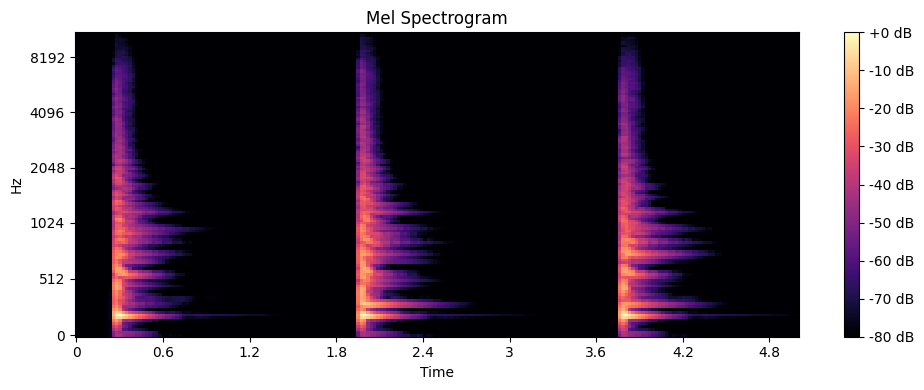

In [14]:
plt.figure(figsize=(10, 4))
librosa.display.specshow(X[0].squeeze(), x_axis='time', y_axis='mel', sr=SAMPLE_RATE)
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram')
plt.tight_layout()
plt.show()

In [ ]:
print("Shape of X:", X.shape)
print("Labels:", set(labels))

Shape of X: (200, 128, 216, 1)
Labels: {'Piano', 'Guitar', 'Violin', 'Drum'}


# Waveform

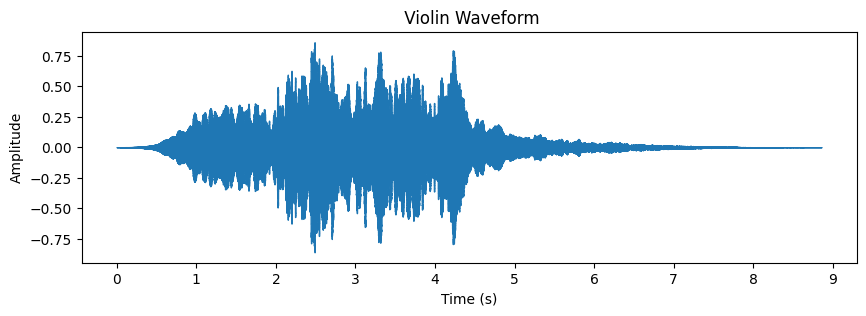

In [7]:
# Load audio file
y, sr = librosa.load('/content/drive/MyDrive/Colab Notebooks/music/Test_submission/Sad-Violin-Slow-K-www.fesliyanstudios.com.wav', sr=None)  # y = waveform, sr = sampling rate

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title(" Violin Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

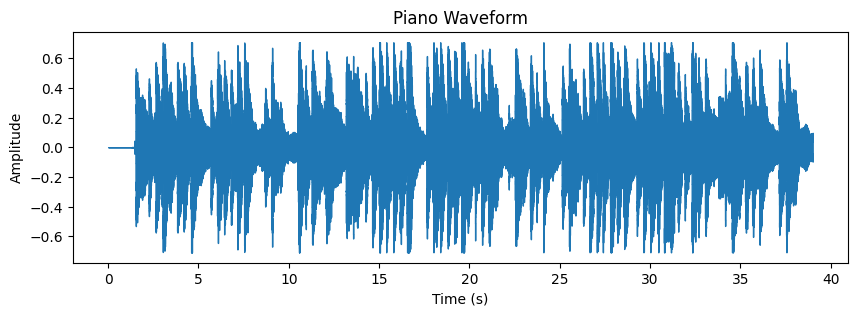

In [8]:
# Load audio file
y, sr = librosa.load('/content/drive/MyDrive/Colab Notebooks/music/Test_submission/ROOM_room6_MUS_pachelbel_DEV_amazon.wav', sr=None)  # y = waveform, sr = sampling rate

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Piano Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

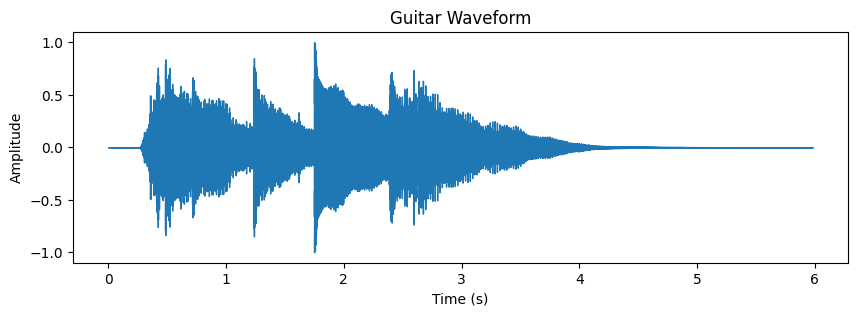

In [9]:
# Load audio file
y, sr = librosa.load('/content/drive/MyDrive/Colab Notebooks/music/Test_submission/acoustic-guitar-logo-13084.wav', sr=None)  # y = waveform, sr = sampling rate

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Guitar Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

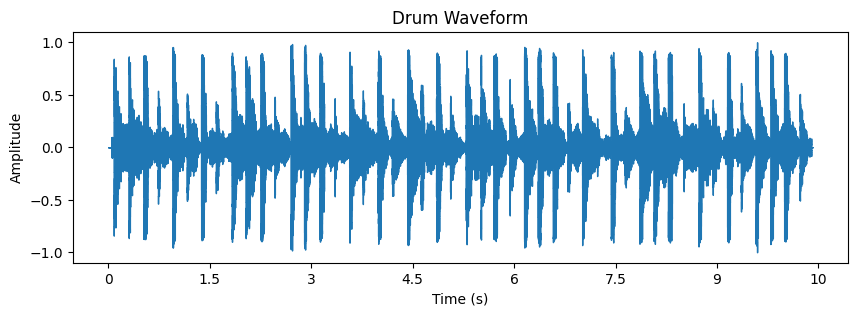

In [10]:
# Load audio file
y, sr = librosa.load('/content/drive/MyDrive/Colab Notebooks/music/Test_submission/rock-drum-loop-85371.wav', sr=None)  # y = waveform, sr = sampling rate

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Drum Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()